# DURUM: Database of Urban RUnoff Microplastics
## Standardization, Correction, and Visualization Code

This notebook reproduces all data standardization protocols, correction factor calculations, and figures presented in:

> Hafiz, A.M., Ahmadisharaf, E., Salehi, M. et al. *A global dataset of microplastics in urban stormwater runoff (2018–2024)*. Sci Data (2026). https://doi.org/10.1038/s41597-026-07137-y

### Notebook Contents
1. **Data Loading** — Load the DURUM dataset
2. **Sampling Method Standardization** — Harmonize sampling method terminology (Figure 3a)
3. **Quantification Method Standardization** — Harmonize analytical methods (Figure 3b)
4. **Sample Volume Standardization** — Parse volumes and assign bins (Figure 3c)
5. **Particle Size Standardization** — Extract numeric sizes and assign bins
6. **Size-Range Correction Factors** — Koelmans et al. (2020) power-law correction (columns x1M_um, x2M_um, CF_1_5000µm, Conc_1_5000µm)
7. **Detection Window Lookup Table** — Complete mapping of Size range → (x1M, x2M)
8. **IQR Validation** — Interquartile ratio reduction analysis
9. **Figure 2** — Global distribution map of sampling locations
10. **Figure 3** — Distribution of sampling methods, quantification techniques, and sample volumes
11. **Figure 4** — Distribution of morphology, polymer types, and size bins by region


## 1. Data Loading

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
file_path = "Urban_Runoff_MP_Database.xlsx"
df = pd.read_excel(file_path, sheet_name="Urban Runoff MP Database")
df.columns = df.columns.str.strip()

print(f"Dataset loaded: {len(df)} records, {len(df.columns)} variables")
print(f"Unique studies: {df['Author (s) and Publication Year'].nunique()}")
print(f"Unique regions: {df['Region'].nunique()}")


Dataset loaded: 180 records, 42 variables
Unique studies: 28
Unique regions: 23


## 2. Sampling Method Standardization

Harmonize diverse sampling terminology into five categories: Composite, Grab, Automated, Engineered Flow, Other.

In [ ]:
import pandas as pd

# Load Dataset 
file_path = "Urban_Runoff_MP_Database.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

# Standardize Quantification Methods 
def standardize_quant_method(text):
    if pd.isna(text):
        return "Other"
    
    text_lower = text.lower()
    methods = set()
    
    if any(keyword in text_lower for keyword in ["atr-ftir", "μftir", "ftir-atr", "ftir"]):
        methods.add("FTIR")
    if "raman" in text_lower:
        methods.add("Raman")
    if any(keyword in text_lower for keyword in ["stereomicroscopy", "visual"]):
        methods.add("Microscopy")
    if "gc-ms" in text_lower or "ted-gc-ms" in text_lower:
        methods.add("GC-MS")
    if "sem" in text_lower:
        methods.add("SEM")
    if "hot needle" in text_lower:
        methods.add("Hot Needle")

    if len(methods) == 0:
        return "Other"
    elif len(methods) == 1:
        return list(methods)[0]
    elif methods == {"FTIR", "Raman"}:
        return "FTIR + Raman"
    else:
        return "Multi-method"


df["Quantification method (standardized)"] = df["Quantification method"].apply(standardize_quant_method)

#  Preview Output
display(df[["Quantification method", "Quantification method (standardized)"]].head(15))




,Quantification method,Quantification method (standardized)
0,ATR-FTIR and Raman microscope,FTIR + Raman
1,ATR-FTIR and Raman microscope,FTIR + Raman
2,ATR-FTIR and Raman microscope,FTIR + Raman
3,ATR-FTIR and Raman microscope,FTIR + Raman
4,ATR-FTIR and Raman microscope,FTIR + Raman
5,ATR-FTIR and Raman microscope,FTIR + Raman
6,"Stereomicroscopy, Raman spectroscopy, FTIR, an...",Multi-method
7,"Stereomicroscopy, Raman spectroscopy, FTIR, an...",Multi-method
8,"Stereomicroscopy, Raman spectroscopy, FTIR, an...",Multi-method
9,"Stereomicroscopy, Raman spectroscopy, FTIR, an...",Multi-method


## 3. Sample Volume Standardization and Binning

Parse sample volumes to liters and assign to standardized bins.

In [ ]:
import pandas as pd
import numpy as np

# Step 1: Load Data 
file_path = "Urban_Runoff_MP_Database.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

#Step 2: Clean Sample Volume Column 
df["Sample volume (cleaned)"] = df["Sample volume"].astype(str).str.lower().str.strip()

# Replace known missing value indicators
df["Sample volume (cleaned)"] = df["Sample volume (cleaned)"].replace({
    "not reported": np.nan,
    "nr": np.nan
})

# Standardize separators and remove 'l'
df["Sample volume (cleaned)"] = df["Sample volume (cleaned)"].str.replace("–", "-", regex=False)
df["Sample volume (cleaned)"] = df["Sample volume (cleaned)"].str.replace("l", "", regex=False)
df["Sample volume (cleaned)"] = df["Sample volume (cleaned)"].str.strip()

# Step 3: Extract numeric volume (handle ranges)
def parse_volume(val):
    try:
        if "-" in val:
            parts = val.split("-")
            parts = [float(p.strip()) for p in parts if p.strip().replace(".", "", 1).isdigit()]
            return sum(parts)/len(parts) if parts else np.nan
        elif val.replace(".", "", 1).isdigit():
            return float(val)
    except:
        return np.nan
    return np.nan

df["Sample volume (L)"] = df["Sample volume (cleaned)"].apply(parse_volume)

#  Step 4: Bin the sample volumes 
def bin_sample_volume(volume):
    if pd.isna(volume):
        return "Not reported"
    elif volume < 5:
        return "Very Small (<5 L)"
    elif volume <= 50:
        return "Small (5–50 L)"
    elif volume <= 250:
        return "Medium (51–250 L)"
    elif volume <= 750:
        return "Large (251–750 L)"
    else:
        return "Very Large (>750 L)"

df["Sample volume bin"] = df["Sample volume (L)"].apply(bin_sample_volume)

#  Step 5: Optional 
output_columns = ["Sample volume", "Sample volume (L)", "Sample volume bin"]
# df[output_columns].to_excel("Sample_Volume_Binned_Output.xlsx", index=False)

df[output_columns].head(10)


,Sample volume,Sample volume (L),Sample volume bin
0,1 L,1.0,Very Small (<5 L)
1,1 L,1.0,Very Small (<5 L)
2,1 L,1.0,Very Small (<5 L)
3,1 L,1.0,Very Small (<5 L)
4,1 L,1.0,Very Small (<5 L)
5,1 L,1.0,Very Small (<5 L)
6,197 L,197.0,Medium (51–250 L)
7,114 L,114.0,Medium (51–250 L)
8,67 L,67.0,Medium (51–250 L)
9,115 L,115.0,Medium (51–250 L)


## 4. Particle Size Standardization

Extract numeric size values from heterogeneous reporting formats and assign to standardized size bins.

In [ ]:
import pandas as pd
import numpy as np
import re

# Load your Excel file
file_path = "Urban_Runoff_MP_Database.xlsx"  
df = pd.read_excel(file_path, sheet_name=0)

# Clean column names
df.columns = df.columns.str.strip()

# Step 1: Extract numeric size (µm) from 'Dominant size'
def extract_corrected_size(value):
    if pd.isna(value):
        return np.nan

    value_str = str(value).lower()

    # Detect the unit (applies to all numbers)
    unit_match = re.search(r"(µm|μm|mm)", value_str)
    if not unit_match:
        return np.nan
    unit = unit_match.group(1)

    # Extract all numeric values
    number_matches = re.findall(r"\d+\.?\d*", value_str)
    if not number_matches:
        return np.nan

    sizes = []
    for num_str in number_matches:
        size = float(num_str)
        if unit.startswith("mm"):
            size *= 1000  # convert mm to µm
        sizes.append(size)

    # Use average of min and max
    if sizes:
        return (min(sizes) + max(sizes)) / 2
    return np.nan

# Step 2: Define standard size bins
def classify_size_bin(size_um):
    if pd.isna(size_um):
        return "Unknown"
    elif size_um < 50:
        return "1–50 µm"
    elif size_um <= 100:
        return "50–100 µm"
    elif size_um <= 500:
        return "100–500 µm"
    elif size_um <= 1000:
        return "500–1000 µm"
    else:
        return ">1000 µm"

# Step 3: Apply both functions to the dataframe
df["Numeric Size (µm)"] = df["Dominant size range"].apply(extract_corrected_size)
df["Standardized Size Bin"] = df["Numeric Size (µm)"].apply(classify_size_bin)

# Step 4: Display the resulting table
output_df = df[["Dominant size range", "Numeric Size (µm)", "Standardized Size Bin"]]
output_df.head(20)  # Show first 20 rows, or remove .head() to display all



,Dominant size range,Numeric Size (µm),Standardized Size Bin
0,1–45 μm,23.0,1–50 µm
1,1–45 μm,23.0,1–50 µm
2,1–45 μm,23.0,1–50 µm
3,1–45 μm,23.0,1–50 µm
4,1–45 μm,23.0,1–50 µm
5,1–45 μm,23.0,1–50 µm
6,125-355 μm,240.0,100–500 µm
7,125-355 μm,240.0,100–500 µm
8,125-355 μm,240.0,100–500 µm
9,125-355 μm,240.0,100–500 µm


## 5. Size-Range Correction Factors

Apply the power-law rescaling method from Koelmans et al. (2020) to correct all concentration 
measurements to an equivalent 1–5000 µm detection range using α = 1.6.

**Detection window assignment:** The `x1M_um` (lower) and `x2M_um` (upper) bounds are extracted 
from the **analytical detection range** reported in each source publication's methodology section 
(the "Size range" column), NOT from the dominant particle size bin. For open-ended ranges 
(e.g., "> 25 µm"), the standard MP upper limit of 5000 µm is assumed. For ambiguous entries 
(e.g., mean ± SD values), the original paper was consulted to determine the actual analytical 
detection window.

The lookup table below documents every unique Size range entry and its assigned (x1M, x2M) bounds.


In [ ]:
import pandas as pd
import numpy as np
import re

# Load dataset
file_path = "Urban_Runoff_MP_Database.xlsx"
df = pd.read_excel(file_path, sheet_name="Urban Runoff MP Database")
df.columns = df.columns.str.strip()

def normalize(s):
    """Normalize string for matching: collapse whitespace, remove special chars"""
    s = str(s).replace('\u202f', ' ').replace('\xa0', ' ').replace('\r', '')
    s = re.sub(r' +', ' ', s).strip()
    return s

# DETECTION WINDOW LOOKUP TABLE
# Each entry maps a 'Size range' value to (lower_µm, upper_µm)
# based on the study's actual analytical detection capabilities.
DETECTION_MAP = {}

# Entries with clearly stated ranges
direct_ranges = {
    "1 µm to 5 mm":       (1, 5000),      
    "125 µm to > 1 mm":   (125, 5000),   
    "37 µm to > 1 mm":    (37, 5000),     
    "25 µm - 1.3 mm":     (25, 1300),    
    "10 μm–5 mm":         (10, 5000),     
    "80–5000 µm":         (80, 5000),     
    "10–2000 μm":         (10, 2000),     
    "0.3 mm – 5.0 mm":    (300, 5000),   
    "0.04 mm - 5 mm":     (40, 5000),    
    "54 µm - <1 mm":      (54, 1000),     
    "20 μm - 6904 μm":    (20, 5000),     
    "5 - 10 μm":          (5, 10),       
    "5 - 100 μm":         (5, 100),      
    "500–2000 µm":        (500, 2000),    
}

# Entries with open-ended bounds (assume 5000 µm upper limit)
open_ended = {
    "> 25 μm":            (25, 5000),     
    "> 300 µm":           (300, 5000),    
    ">125 µm":            (125, 5000),    
    "125 - >500 μm":      (125, 5000),   
    "106 µm - >1 mm":     (106, 5000),    
    "< 50 μm - > 3000 μm": (50, 5000),   
    "<0.1 mm - 5 mm":     (100, 5000),    
}

paper_verified = {
    "243 ± 129 µm":   (25, 5000),   
    "290 ± 213 µm":   (25, 5000),  
    "243 ± 151 µm":   (25, 5000),   
    "157 ± 71 µm":    (25, 5000),   
    "<500 µm":        (20, 100),   
    "Not reported":   (200, 5000),  
}

# Build normalized map
for d in [direct_ranges, open_ended, paper_verified]:
    for k, v in d.items():
        DETECTION_MAP[normalize(k)] = v

# Add multiline entries (contain newlines in the original data)
for sr in df['Size range'].unique():
    n = normalize(sr)
    if n not in DETECTION_MAP:
        if '250' in str(sr) and '2000' in str(sr):
            DETECTION_MAP[n] = (250, 2000)  # Combined 250–500 + 500–2000 µm fractions
        elif '>1000' in str(sr) and '10-50' in str(sr):
            DETECTION_MAP[n] = (10, 5000)   # Full range from 10-50 µm up to >1000 µm bins
        elif '≥' in str(sr) and '20' in str(sr):
            DETECTION_MAP[n] = (20, 5000)   # ≥20 µm, open upper
        elif '25' in str(sr) and '1 mm' in str(sr) and '100' in str(sr):
            DETECTION_MAP[n] = (25, 1000)   # 25 µm to 1 mm range
        elif '500-1000' in str(sr) and '1000-5000' in str(sr):
            DETECTION_MAP[n] = (500, 5000)  # Combined 500-1000 + 1000-5000 µm fractions


# KOELMANS CORRECTION FACTOR FUNCTION

def correction_factor_powerlaw(x1M, x2M, alpha=1.6, x1D=1.0, x2D=5000.0):
    """
    Compute the Koelmans-style correction factor CF.
    
    Converts a concentration measured over [x1M, x2M] to an equivalent
    concentration over the default range [x1D, x2D] = [1, 5000] µm.
    
    Based on: Koelmans et al. (2020) Environ. Sci. Technol. 54, 12307-12315.
    
    CF = ∫[x1D,x2D] x^(-α) dx / ∫[x1M,x2M] x^(-α) dx
    
    Parameters
    ----------
    x1M, x2M : float — Measured detection window bounds (µm)
    alpha : float — Power-law exponent (default 1.6)
    x1D, x2D : float — Default full range [1, 5000] µm
    
    Returns
    -------
    CF : float — Multiplicative correction factor
    """
    if pd.isna(x1M) or pd.isna(x2M) or x1M <= 0 or x2M <= 0:
        return np.nan
    num = (x2D ** (1 - alpha)) - (x1D ** (1 - alpha))
    den = (x2M ** (1 - alpha)) - (x1M ** (1 - alpha))
    return np.nan if den == 0 else num / den


# APPLY CORRECTION TO DATASET

def get_window(sr):
    return DETECTION_MAP.get(normalize(sr), None)

new_x1, new_x2, new_cf, new_conc = [], [], [], []
for _, row in df.iterrows():
    w = get_window(row['Size range'])
    if w is None:
        new_x1.append(np.nan); new_x2.append(np.nan)
        new_cf.append(np.nan); new_conc.append(np.nan)
    else:
        x1, x2 = w
        cf = correction_factor_powerlaw(x1, x2)
        sc = row['Standardized Concentration (particles/L)']
        new_x1.append(x1); new_x2.append(x2); new_cf.append(cf)
        new_conc.append(sc * cf if not pd.isna(sc) and not pd.isna(cf) else np.nan)

df['x1M_um'] = new_x1
df['x2M_um'] = new_x2
df['CF_1_5000µm'] = new_cf
df['Conc_1_5000µm (particles/L)'] = new_conc

# Print summary
print(f"Records with correction factors: {df['CF_1_5000µm'].notna().sum()} / {len(df)}")
print(f"CF range: {df['CF_1_5000µm'].min():.2f} – {df['CF_1_5000µm'].max():.2f}")
print(f"CF median: {df['CF_1_5000µm'].median():.2f}")

# Print the complete lookup table
print("\n=== Detection Window Lookup Table ===")
print(f"{'Size range':<55} {'x1M':>6} {'x2M':>6} {'CF':>8} {'n':>4}")
print("-" * 85)
for sr in df['Size range'].unique():
    w = get_window(sr)
    n = len(df[df['Size range'] == sr])
    sr_disp = normalize(str(sr))[:53]
    if w:
        cf = correction_factor_powerlaw(w[0], w[1])
        print(f"  {sr_disp:<53} {w[0]:>6.0f} {w[1]:>6.0f} {cf:>8.2f} {n:>4}")
    else:
        print(f"  {sr_disp:<53} {'N/A':>6} {'N/A':>6} {'N/A':>8} {n:>4}")

# # Save updated dataset
# output_path = "Urban Runoff MP Database_withCF.xlsx"
# df.to_excel(output_path, sheet_name='Urban Runoff MP Database', index=False)
# print(f"\nSaved corrected dataset: {output_path}")


Records with correction factors: 162 / 180
CF range: 1.00 – 73.27
CF median: 9.62

=== Detection Window Lookup Table ===
Size range                                                 x1M    x2M       CF    n
-------------------------------------------------------------------------------------
  1 µm to 5 mm                                               1   5000     1.00    6
  125 µm to > 1 mm                                         125   5000    20.22   12
  37 µm to > 1 mm                                           37   5000     9.16   15
  25 µm to 5000 µm                                         N/A    N/A      N/A    4
  ≥ 20 µm and
≥ 100 µm                                      20   5000     6.22    1
  20 µm to 100 µm                                          N/A    N/A      N/A    9
  25 µm - 1.3 mm                                            25   1300     7.56   18
  10 μm–5 mm                                                10   5000     4.05    2
  > 25 μm                            

## 6. Power-Law Correction Validation

Validate the correction by comparing interquartile ratios before and after size-range normalization.

In [ ]:
# IQR validation
std_conc = df['Standardized Concentration (particles/L)'].dropna()
std_nz = std_conc[std_conc > 0]
corr_conc = df['Conc_1_5000µm (particles/L)'].dropna()
corr_nz = corr_conc[corr_conc > 0]

iqr_original = std_nz.quantile(0.75) / std_nz.quantile(0.25)
iqr_corrected = corr_nz.quantile(0.75) / corr_nz.quantile(0.25)

print(f"IQR75/IQR25 ratio — Original (uncorrected): {iqr_original:.1f}")
print(f"IQR75/IQR25 ratio — After size correction:  {iqr_corrected:.1f}")
print(f"Reduction factor: {iqr_original/iqr_corrected:.1f}x")

print(f"\nCorrected concentration range: {corr_conc.min():.2f} – {corr_conc.max():.0f} particles/L")
print(f"Corrected concentration median: {corr_conc.median():.1f} particles/L")


IQR75/IQR25 ratio — Original (uncorrected): 58.7
IQR75/IQR25 ratio — After size correction:  34.6
Reduction factor: 1.7x

Corrected concentration range: 0.00 – 309341 particles/L
Corrected concentration median: 197.5 particles/L


## 7. Figure 2 — Global Distribution of Sampling Locations

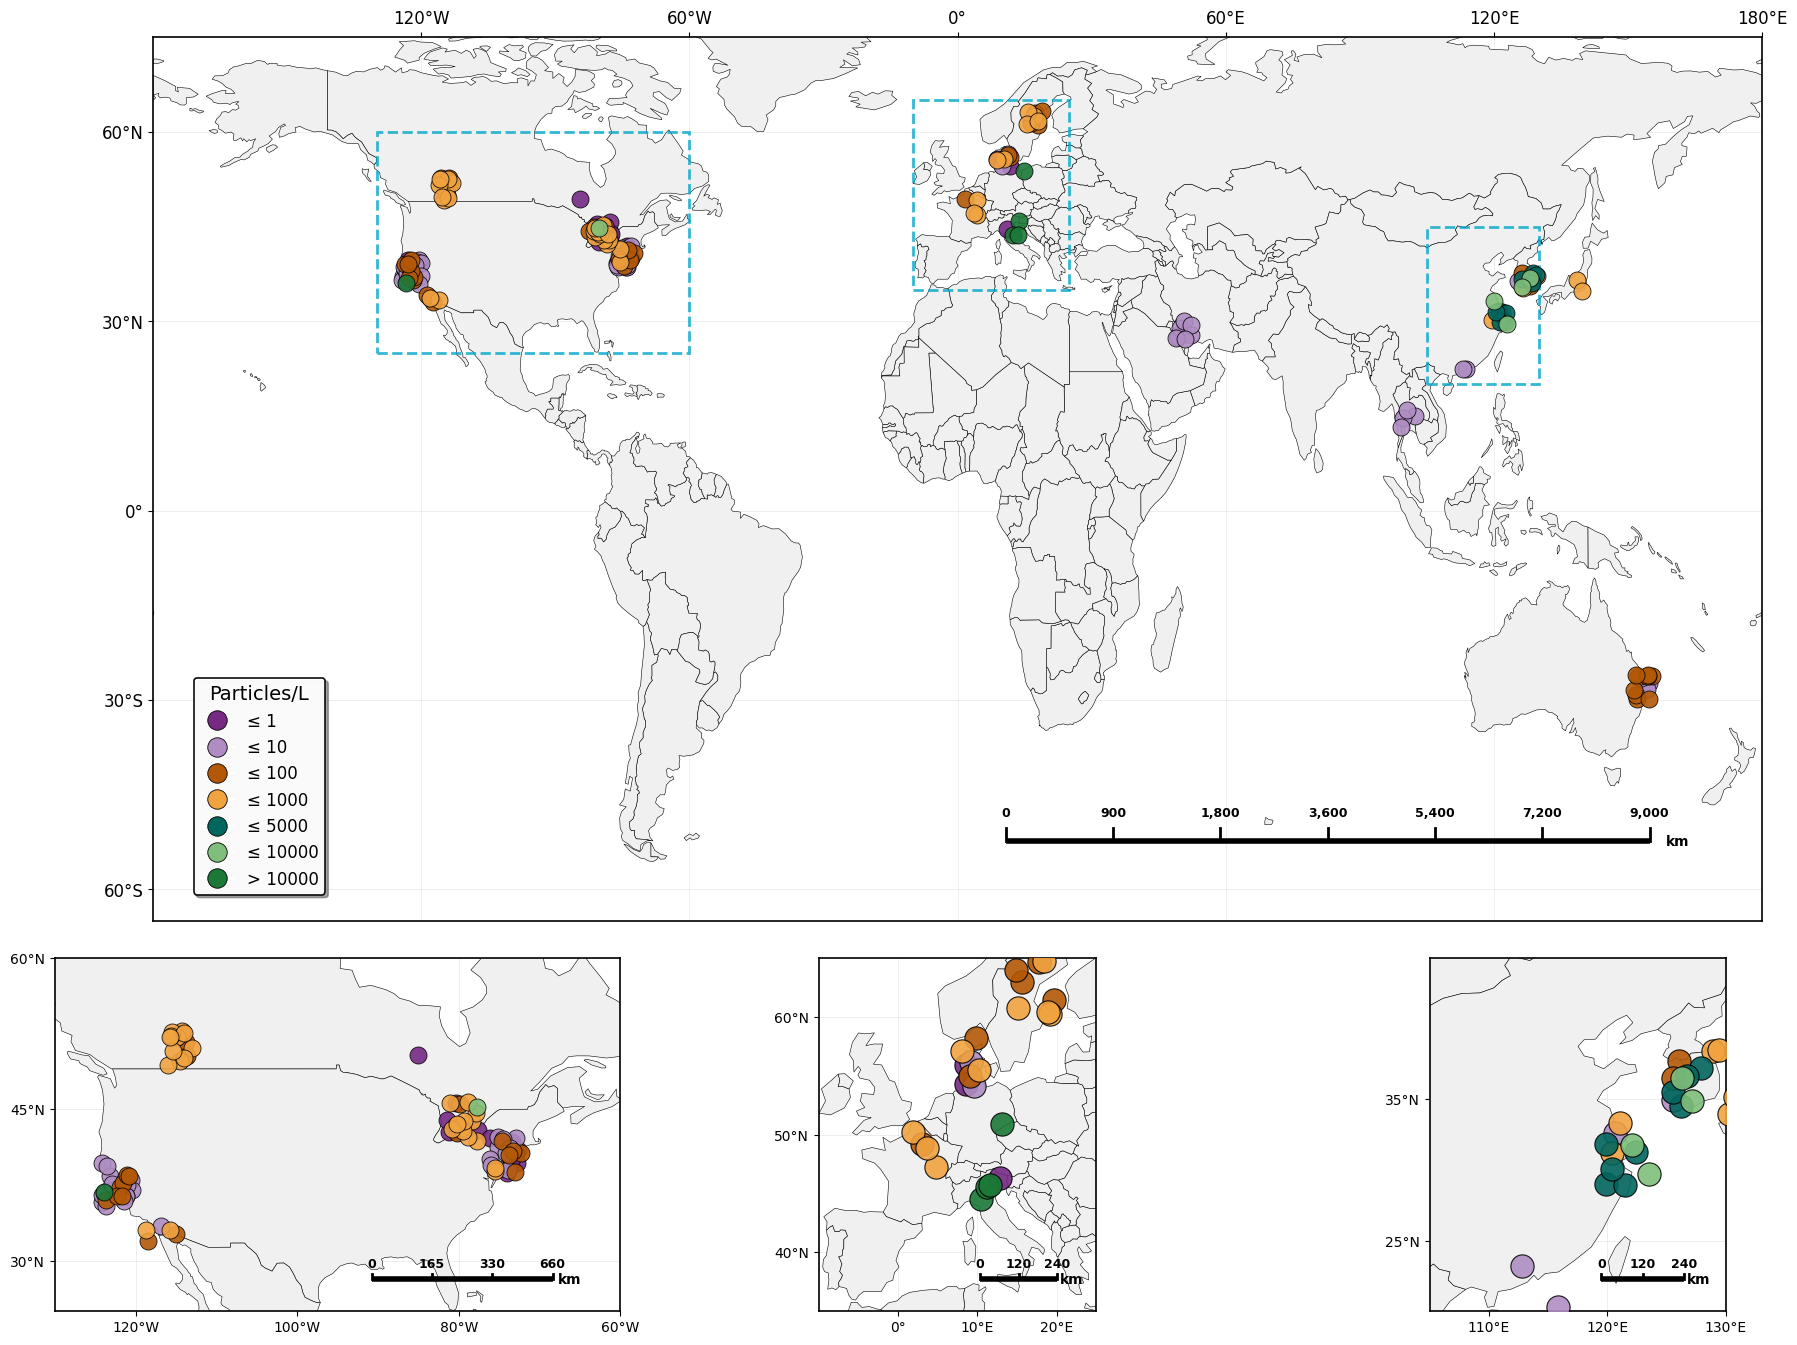

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, Polygon, FancyBboxPatch
import matplotlib.gridspec as gridspec
from matplotlib.patches import Wedge
import matplotlib.patches as patches
from matplotlib.lines import Line2D

def create_reference_style_map():
    # Load the Excel file
    df = pd.read_excel("Urban_Runoff_MP_Database.xlsx", sheet_name="Urban Runoff MP Database")
    
    # Drop rows missing concentration or coordinates
    df = df.dropna(subset=["Standardized Concentration (particles/L)", "Decimal Latitude", "Decimal Longitude"])
    
    # Use your specified bins and colors
    bins = [0, 1, 10, 100, 1000, 5000, 10000, 20000]
    labels = ['≤ 1', '≤ 10', '≤ 100', '≤ 1000', '≤ 5000', '≤ 10000', '> 10000']
    colors = ['#762a83',
'#af8dc3',
'#b35806',
'#f1a340',
'#01665e',
'#7fbf7b',
'#1b7837']
    
    # Assign bin labels
    df["MP_bin"] = pd.cut(df["Standardized Concentration (particles/L)"], bins=bins, labels=labels, include_lowest=True)
    color_map = dict(zip(labels, colors))
    
    # Load world shapefile
    shapefile_path = "ne_110m_admin_0_countries\ne_110m_admin_0_countries.shp"
    world = gpd.read_file(shapefile_path)
    world = world[world["NAME"] != "Antarctica"]
    
    # Create figure with three insets
    fig = plt.figure(figsize=(20, 14))
    # Use GridSpec with equal width ratios for perfect alignment
    gs = gridspec.GridSpec(2, 3, figure=fig, 
                          height_ratios=[2.5, 1], width_ratios=[1, 1, 1],
                          hspace=0.06, wspace=0.0)  # Reduce hspace/wspace for tight alignment
    
    # Main world map (spans full width)
    ax_main = fig.add_subplot(gs[0, :])
    ax_main.set_aspect("equal")

    # Three insets, perfectly aligned under the main map
    ax_north_america = fig.add_subplot(gs[1, 0])
    ax_europe = fig.add_subplot(gs[1, 1])
    ax_asia = fig.add_subplot(gs[1, 2])
    
    # Function to add reference-style scale bar
    def add_reference_scale_bar(ax, extent, position='bottom_right'):
        width = extent[1] - extent[0]
        height = extent[3] - extent[2]

        # Determine scale based on map width
        if width > 200:  # World map
            distances = [0, 900, 1800, 3600, 5400, 7200, 9000]  # km
            bar_length = width * 0.4
            margin_x = width * 0.07
        elif width > 50:  # Regional map
            distances = [0, 165, 330, 660]  # km
            bar_length = width * 0.32  # slightly shorter
            margin_x = width * 0.12    # increase margin to avoid border
        else:  # Detailed map
            distances = [0, 120, 240]  # km
            bar_length = width * 0.28  # shorter for detailed
            margin_x = width * 0.14    # more margin for small maps

        # Set fixed margin from the edges (increase margin to avoid overlap)
        margin_y = height * 0.09

        # Positioning logic
        if position == 'bottom_right':
            x_start = extent[1] - bar_length - margin_x
            y_pos = extent[2] + margin_y
        elif position == 'bottom_left':
            x_start = extent[0] + margin_x
            y_pos = extent[2] + margin_y
        elif position == 'top_left':
            x_start = extent[0] + margin_x
            y_pos = extent[3] - margin_y - height * 0.03
        elif position == 'top_right':
            x_start = extent[1] - bar_length - margin_x
            y_pos = extent[3] - margin_y - height * 0.03
        else:
            x_start = extent[1] - bar_length - margin_x
            y_pos = extent[2] + margin_y

        # Draw main scale line
        ax.plot([x_start, x_start + bar_length], [y_pos, y_pos],
                'k-', linewidth=4, solid_capstyle='butt', zorder=20)

        # Add tick marks and labels (tick marks on top)
        for i, distance in enumerate(distances):
            x_pos = x_start + (i / (len(distances) - 1)) * bar_length
            tick_height = height * 0.015
            # Tick mark on top of the scale bar
            ax.plot([x_pos, x_pos], [y_pos, y_pos + tick_height],
                    'k-', linewidth=2, zorder=21)
            # Label above the tick
            ax.text(x_pos, y_pos + tick_height + height * 0.01, f'{distance:,}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold', zorder=22)

        # Add unit label ("km") just to the right of the scale bar, beside the last tick
        ax.text(x_start + bar_length + width * 0.01, y_pos,
                'km', ha='left', va='center', fontsize=10, fontweight='bold', zorder=22)
    
    # Function to style axes
    def style_axis(ax, extent, add_grid=True, tick_position='bottom'):
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_aspect('equal')
        
        if add_grid:
            ax.grid(True, linestyle='-', alpha=0.3, linewidth=0.5)
            ax.set_axisbelow(True)
        
        # Style spines
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
            spine.set_color('black')
        
        # Set tick positions
        if tick_position == 'top':
            ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
        else:
            ax.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True)
    
    # Function to plot data on axis with scale-appropriate jitter
    def plot_on_axis(ax, extent, add_points=True):
        # Plot world countries
        world.plot(ax=ax, facecolor='#f0f0f0', edgecolor='black', linewidth=0.4)
        
        if add_points:
            # Filter points within extent with buffer
            buffer = 5
            mask = ((df["Decimal Longitude"] >= extent[0] - buffer) & 
                   (df["Decimal Longitude"] <= extent[1] + buffer) & 
                   (df["Decimal Latitude"] >= extent[2] - buffer) & 
                   (df["Decimal Latitude"] <= extent[3] + buffer))
            df_subset = df[mask].copy()
            
            if len(df_subset) == 0:
                return
            
            # Calculate appropriate jitter for this scale
            lon_range = extent[1] - extent[0]
            
            # Scale jitter based on map extent
            if lon_range < 50:  # Inset maps
                jitter_scale = 2.5
            else:  # Main map
                jitter_scale = 2
            
            # Apply scaled jitter
            np.random.seed(42)
            df_subset["Longitude_display"] = df_subset["Decimal Longitude"] + np.random.uniform(-jitter_scale, jitter_scale, size=len(df_subset))
            df_subset["Latitude_display"] = df_subset["Decimal Latitude"] + np.random.uniform(-jitter_scale, jitter_scale, size=len(df_subset))
            
            # Create geometry for this subset
            geometry_subset = [Point(xy) for xy in zip(df_subset["Longitude_display"], df_subset["Latitude_display"])]
            gdf_subset = gpd.GeoDataFrame(df_subset, geometry=geometry_subset, crs="EPSG:4326")
            
            # Plot each concentration category
            for label in labels:
                subset = gdf_subset[gdf_subset["MP_bin"] == label]
                if not subset.empty:
                    # Adjust marker size based on map scale
                    if lon_range < 50:  # Inset maps
                        marker_size = 280
                        edge_width = 0.8
                    else:  # Main map
                        marker_size = 150
                        edge_width = 0.6
                    
                    subset.plot(
                        ax=ax,
                        markersize=marker_size,
                        color=color_map[label],
                        edgecolor='black',
                        linewidth=edge_width,
                        alpha=0.9,
                        zorder=10
                    )
    
    # Function to add connecting lines from insets to main map
    def add_connecting_lines():
        # Get figure coordinates for drawing lines
        fig_width, fig_height = fig.get_size_inches()
        
        # North America connections
        na_main_x = 0.17  # aligned with left inset
        na_main_y = 0.65
        na_inset_x = 0.17
        na_inset_y = 0.35
        
        # Add dashed lines
        line_na = Line2D([na_main_x, na_inset_x], [na_main_y, na_inset_y], 
                        transform=fig.transFigure, color='#00a6ca', 
                        linestyle='--', linewidth=2, alpha=0.8)
        fig.lines.append(line_na)
        
        # Europe connections  
        eu_main_x = 0.5
        eu_main_y = 0.65
        eu_inset_x = 0.5
        eu_inset_y = 0.35
        
        line_eu = Line2D([eu_main_x, eu_inset_x], [eu_main_y, eu_inset_y], 
                        transform=fig.transFigure, color='#00a6ca', 
                        linestyle='--', linewidth=2, alpha=0.8)
        fig.lines.append(line_eu)
        
        # Asia connections
        asia_main_x = 0.83  # aligned with right inset
        asia_main_y = 0.65
        asia_inset_x = 0.83
        asia_inset_y = 0.35
        
        line_asia = Line2D([asia_main_x, asia_inset_x], [asia_main_y, asia_inset_y], 
                          transform=fig.transFigure, color='#00a6ca', 
                          linestyle='--', linewidth=2, alpha=0.8)
        fig.lines.append(line_asia)
    
    # Main map
    main_extent = [-180, 180, -65, 75]
    style_axis(ax_main, main_extent, tick_position='top')
    plot_on_axis(ax_main, main_extent)
    
    # Add degree labels to main map (on top)
    ax_main.set_xticks(np.arange(-120, 181, 60))
    ax_main.set_yticks(np.arange(-60, 61, 30))
    ax_main.set_xticklabels([f'{abs(x)}°{"W" if x < 0 else "E" if x > 0 else ""}' for x in np.arange(-120, 181, 60)])
    ax_main.set_yticklabels([f'{abs(y)}°{"S" if y < 0 else "N" if y > 0 else ""}' for y in np.arange(-60, 61, 30)])
    
    # North America inset
    north_america_extent = [-130, -60, 25, 60]
    style_axis(ax_north_america, north_america_extent)
    plot_on_axis(ax_north_america, north_america_extent)
    ax_north_america.set_xticks(np.arange(-120, -59, 20))
    ax_north_america.set_yticks(np.arange(30, 61, 15))
    ax_north_america.set_xticklabels([f'{abs(x)}°W' for x in np.arange(-120, -59, 20)])
    ax_north_america.set_yticklabels([f'{y}°N' for y in np.arange(30, 61, 15)])
    
    # Europe inset
    europe_extent = [-10, 25, 35, 65]
    style_axis(ax_europe, europe_extent)
    plot_on_axis(ax_europe, europe_extent)
    ax_europe.set_xticks(np.arange(0, 21, 10))
    ax_europe.set_yticks(np.arange(40, 61, 10))
    ax_europe.set_xticklabels([f'{x}°E' if x > 0 else '0°' for x in np.arange(0, 21, 10)])
    ax_europe.set_yticklabels([f'{y}°N' for y in np.arange(40, 61, 10)])
    
    # Asia inset
    asia_extent = [105, 130, 20, 45]
    style_axis(ax_asia, asia_extent)
    plot_on_axis(ax_asia, asia_extent)
    ax_asia.set_xticks(np.arange(110, 131, 10))
    ax_asia.set_yticks(np.arange(25, 41, 10))
    ax_asia.set_xticklabels([f'{x}°E' for x in np.arange(110, 131, 10)])
    ax_asia.set_yticklabels([f'{y}°N' for y in np.arange(25, 41, 10)])
    
    # Add dashed boxes connecting insets to main map
    na_box = Rectangle((-130, 25), 70, 35, linewidth=2, edgecolor='#00a6ca', 
                      facecolor='none', linestyle='--', alpha=0.8)
    ax_main.add_patch(na_box)
    europe_box = Rectangle((-10, 35), 35, 30, linewidth=2, edgecolor='#00a6ca', 
                          facecolor='none', linestyle='--', alpha=0.8)
    ax_main.add_patch(europe_box)
    asia_box = Rectangle((105, 20), 25, 25, linewidth=2, edgecolor='#00a6ca',
                        facecolor='none', linestyle='--', alpha=0.8)
    ax_main.add_patch(asia_box)
    
    # Create legend with your colors
    legend_elements = []
    for label, color in color_map.items():
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor=color, markersize=14,
                                        markeredgecolor='black', markeredgewidth=0.6,
                                        label=label))
    
    # Position legend in main map
    legend = ax_main.legend(handles=legend_elements, title='Particles/L', 
                           loc='lower left', frameon=True, fancybox=True,
                           shadow=True, fontsize=12, title_fontsize=14,
                           bbox_to_anchor=(0.02, 0.02))
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.95)
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1.2)
    
    # Add reference-style scale bars
    add_reference_scale_bar(ax_main, main_extent,position='bottom_right')
    add_reference_scale_bar(ax_north_america, north_america_extent)
    add_reference_scale_bar(ax_europe, europe_extent)
    add_reference_scale_bar(ax_asia, asia_extent)
    
    
    # Clean up tick labels for insets
    ax_north_america.tick_params(labelsize=10)
    ax_europe.tick_params(labelsize=10)
    ax_asia.tick_params(labelsize=10)
    ax_main.tick_params(labelsize=12)
    
    # Adjust layout for perfect alignment
    plt.subplots_adjust(left=0.05, right=0.98, top=0.97, bottom=0.06, hspace=0.06, wspace=0.0)
    
    # Save high-resolution figure
    plt.savefig('microplastics_reference_style.svg', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.show()
    
    return fig

# Alternative color schemes you can try
def alternative_color_schemes():
    """Different color schemes for the map"""
    
    # Viridis-inspired
    viridis_colors = ['#440154', '#31688e', '#35b779', '#6ece58', '#b5de2b', '#fde725']
    
    # Blue to red
    blue_red = ['#053061', '#2166ac', '#4393c3', '#92c5de', '#fdbf6f', '#fd8d3c', '#d73027']
    
    # Spectral
    spectral = ['#2b83ba', '#abdda4', '#ffffbf', '#fdae61', '#d7191c']
    
    return viridis_colors, blue_red, spectral

if __name__ == "__main__":
    # Create the map
    fig = create_reference_style_map()

## 8. Figure 3 — Distribution of Sampling Methods, Quantification Techniques, and Sample Volumes

Horizontal bar charts showing the count of records for each standardized category.

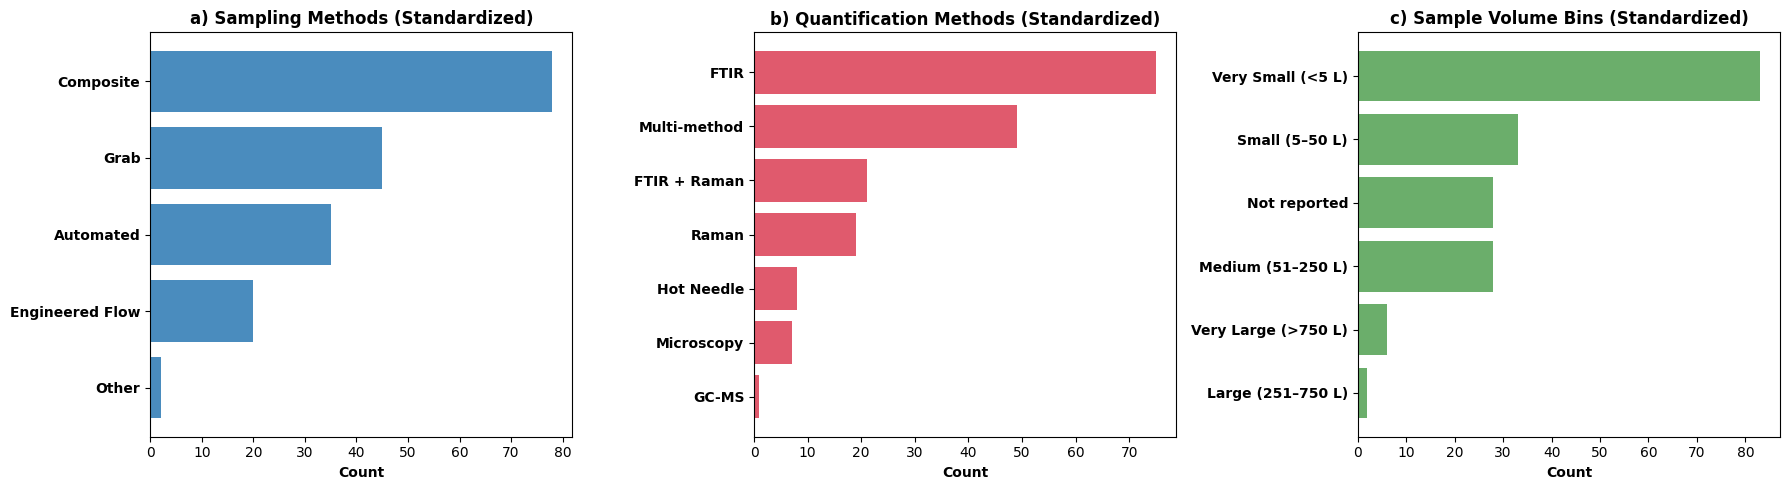

Figure 3 saved.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Sampling Methods
sampling_order = df['Sampling method (standardized)'].value_counts().index
axes[0].barh(range(len(sampling_order)), 
             [df['Sampling method (standardized)'].value_counts()[m] for m in sampling_order],
             color='#4a8cbe')
axes[0].set_yticks(range(len(sampling_order)))
axes[0].set_yticklabels(sampling_order, fontweight='bold')
axes[0].set_xlabel('Count', fontweight='bold')
axes[0].set_title('a) Sampling Methods (Standardized)', fontweight='bold')
axes[0].invert_yaxis()

# (b) Quantification Methods
quant_order = df['Quantification method (standardized)'].value_counts().index
axes[1].barh(range(len(quant_order)),
             [df['Quantification method (standardized)'].value_counts()[q] for q in quant_order],
             color='#e05a6d')
axes[1].set_yticks(range(len(quant_order)))
axes[1].set_yticklabels(quant_order, fontweight='bold')
axes[1].set_xlabel('Count', fontweight='bold')
axes[1].set_title('b) Quantification Methods (Standardized)', fontweight='bold')
axes[1].invert_yaxis()

# (c) Sample Volume Bins
vol_order = ['Very Small (<5 L)', 'Small (5–50 L)', 'Not reported', 
             'Medium (51–250 L)', 'Very Large (>750 L)', 'Large (251–750 L)']
vol_order = [v for v in vol_order if v in df['Sample volume bin'].values]
axes[2].barh(range(len(vol_order)),
             [df['Sample volume bin'].value_counts().get(v, 0) for v in vol_order],
             color='#6bae6b')
axes[2].set_yticks(range(len(vol_order)))
axes[2].set_yticklabels(vol_order, fontweight='bold')
axes[2].set_xlabel('Count', fontweight='bold')
axes[2].set_title('c) Sample Volume Bins (Standardized)', fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
# plt.savefig('Figure_3_methods_distribution.png', dpi=300, bbox_inches='tight')
# plt.savefig('Figure_3_methods_distribution.svg', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")


## 9. Figure 4 — Distribution of Morphology, Polymer Type, and Size Bins by Region

Stacked bar charts showing the proportional distribution across regions with n ≥ 5 records.

Total records: 179

Region distribution:
Region
California               26
New Jersey               24
Ontario                  24
Alberta                  15
Queensland               13
Shanghai City            10
Sundsvall                 9
Wuhan                     8
Bushehr                   8
Gumi                      6
Daejeon                   5
Tijuana                   5
Aarhus                    5
Paris                     4
Pathum Thani province     4
Vanice                    4
Victoria Harbor           2
Tokyo                     2
Cheonan City              2
Gothenburg                1
Silkeborg                 1
Viborg                    1
Name: count, dtype: int64

MORPHOLOGY ANALYSIS BY REGION
Top shapes: ['Fiber', 'Fragment', 'Tire Wear Particles\n(Twps)', 'Film', 'Granule']
Regions with morphology data: ['Alberta', 'Bushehr', 'California', 'Gumi', 'New Jersey', 'Ontario', 'Queensland', 'Shanghai City', 'Sundsvall', 'Tijuana', 'Wuhan']

POLYMER COMPOSITION ANALYSIS B

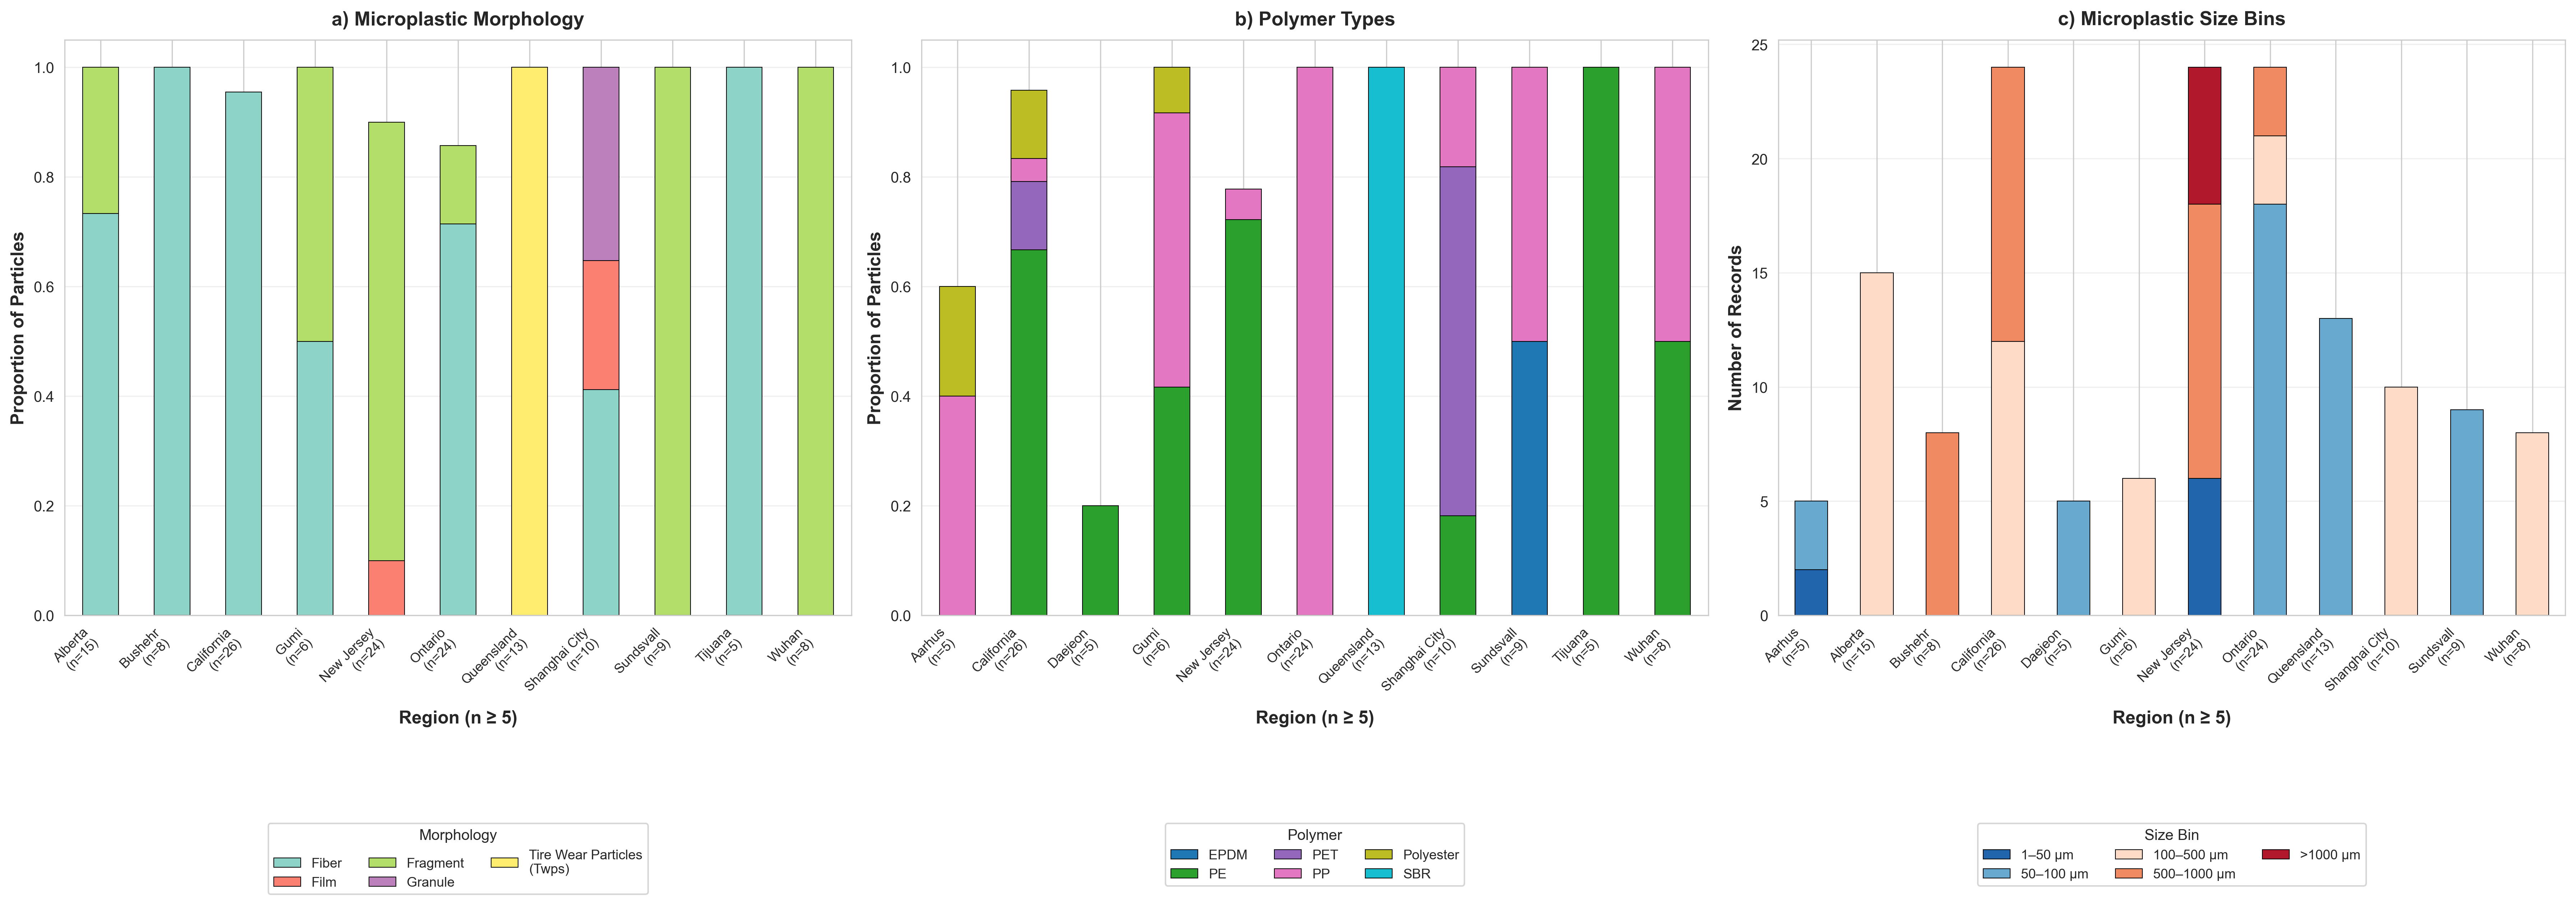


Figure 4 saved: Figure_4_morphology_polymer_size_by_region.png/.svg

STATISTICAL TESTS

Morphology distribution by region:
  Chi-square test: χ² = 350.15, df = 70, p = 7.211e-39
  → DIFFERS significantly

Polymer composition by region:
  Chi-square test: χ² = 518.50, df = 100, p = 9.733e-58
  → DIFFERS significantly

Size bin distribution by region:
  Chi-square test: χ² = 278.02, df = 44, p = 9.895e-36
  → DIFFERS significantly

ANALYSIS COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300

file_path = "Urban_Runoff_MP_Database.xlsx"

try:
    df = pd.read_excel(file_path, sheet_name="Urban Runoff MP Database", engine='openpyxl')
except:
    df = pd.read_excel(file_path, sheet_name=0)

df.columns = df.columns.str.strip()

# Get standardized concentration
conc_col = "Standardized Concentration (particles/L)"
df_clean = df[pd.to_numeric(df[conc_col], errors="coerce").notna()].copy()
df_clean[conc_col] = df_clean[conc_col].astype(float)

# Use Region column directly
df_clean['Region'] = df_clean['Region'].astype(str).str.strip()
df_clean = df_clean[df_clean['Region'] != 'nan']

print(f"Total records: {len(df_clean)}")
print(f"\nRegion distribution:")
region_counts = df_clean['Region'].value_counts()
print(region_counts)

# Regions with n >= 5
min_n_region = 5
regions_to_analyze = region_counts[region_counts >= min_n_region].index


# MORPHOLOGY

print("\n" + "="*80)
print("MORPHOLOGY ANALYSIS BY REGION")
print("="*80)

def split_shapes(x):
    if pd.isna(x):
        return []
    parts = re.split(r'[;,/&]\s*|\s+and\s+', str(x).lower())
    shape_map = {
        'fiber': 'Fiber', 'fibers': 'Fiber', 'fibres': 'Fiber',
        'fragment': 'Fragment', 'fragments': 'Fragment',
        'film': 'Film', 'films': 'Film',
        'sphere': 'Sphere', 'spheres': 'Sphere', 'bead': 'Sphere', 'beads': 'Sphere',
        'tire': 'Tire Wear Particle', 'twp': 'Tire Wear Particle', 'twps': 'Tire Wear Particle',
        'tire wear': 'Tire Wear Particle', 'tire wear particle': 'Tire Wear Particle',
        'tire wear particles': 'Tire Wear Particle',
        'foam': 'Foam', 'pellet': 'Pellet', 'pellets': 'Pellet',
        'granule': 'Granule', 'granules': 'Granule'
    }
    exclude_terms = ['not reported', 'not discussed', 'not', 'and', 'or', 'the']
    cleaned = []
    for part in parts:
        part = part.strip()
        if part in exclude_terms or len(part) < 3:
            continue
        if part in shape_map:
            cleaned.append(shape_map[part])
        elif part and 'rubber' not in part.lower():
            cleaned.append(part.title())
    return cleaned if cleaned else []

df_clean['shape_list'] = df_clean['Dominant shape'].apply(split_shapes)
df_shapes = df_clean.explode('shape_list')
df_shapes = df_shapes[df_shapes['shape_list'].notna() & (df_shapes['shape_list'] != '')]
df_shapes_filtered = df_shapes[df_shapes['Region'].isin(regions_to_analyze)].copy()

shape_by_region = df_shapes_filtered.groupby(['Region', 'shape_list']).size().reset_index(name='count')
region_totals_shapes = shape_by_region.groupby('Region')['count'].sum().reset_index(name='total')
shape_by_region = shape_by_region.merge(region_totals_shapes, on='Region')
shape_by_region['proportion'] = shape_by_region['count'] / shape_by_region['total']

top_shapes = df_shapes['shape_list'].value_counts().head(5).index.tolist()
shape_pivot = shape_by_region[shape_by_region['shape_list'].isin(top_shapes)].pivot(
    index='Region', columns='shape_list', values='proportion'
).fillna(0)

print(f"Top shapes: {top_shapes}")
print(f"Regions with morphology data: {shape_pivot.index.tolist()}")


# POLYMER 

print("\n" + "="*80)
print("POLYMER COMPOSITION ANALYSIS BY REGION")
print("="*80)

def split_polymers(x):
    if pd.isna(x):
        return []
    text = str(x)
    skip_terms = ['not reported', 'not discussed', 'discussed', 'anthropogenic', 'dye-based',
                  'cellulose', 'celleulose', 'bitumen', 'bitument', 'rubber (ru)', 'tire wear']
    if any(skip.lower() in text.lower() for skip in skip_terms):
        return []
    parts = re.split(r'[;,/&]\s*|\s+and\s+', text)
    polymer_map = {
        'pe': 'PE', 'polyethylene': 'PE', 'polyethylene (pe)': 'PE',
        'pp': 'PP', 'polypropylene': 'PP', 'polypropylene (pp)': 'PP',
        'pet': 'PET', 'polyethylene terephthalate': 'PET', 'polyethylene terephthalate (pet)': 'PET',
        'polyethylence terepthalate': 'PET',
        'ps': 'PS', 'polystyrene': 'PS', 'polystyrene (ps)': 'PS',
        'pvc': 'PVC', 'polyvinyl chloride': 'PVC', 'polyvinyl chloride (pvc)': 'PVC',
        'sbr': 'SBR', 'styrene-butadiene rubber': 'SBR', 'styrene butadiene rubber': 'SBR',
        'styrene-butadiene rubber (sbr)': 'SBR',
        'epdm': 'EPDM', 'ethylene propylene diene monomer': 'EPDM',
        'pa': 'PA', 'polyamide': 'PA', 'nylon': 'PA', 'polyamide (pa)': 'PA', 'nylon (pa)': 'PA',
        'pu': 'PU', 'polyurethane': 'PU', 'polyurethane (pu)': 'PU',
        'pes': 'Polyester', 'polyester': 'Polyester', 'polyester (pes)': 'Polyester',
        'acrylic': 'Acrylic', 'polyacrylates': 'Acrylic', 'polyacrylamide': 'Acrylic'
    }
    cleaned = []
    for part in parts:
        part = part.strip().lower()
        part = re.sub(r'\([^)]*\)', '', part).strip()
        part = re.sub(r'\s+', ' ', part)
        if len(part) < 2:
            continue
        if part in polymer_map:
            polymer = polymer_map[part]
            if polymer not in cleaned:
                cleaned.append(polymer)
    return cleaned if cleaned else []

df_clean['polymer_list'] = df_clean['Dominant polymer (s)'].apply(split_polymers)
df_polymers = df_clean.explode('polymer_list')
df_polymers = df_polymers[df_polymers['polymer_list'].notna() & (df_polymers['polymer_list'] != '')]
df_polymers_filtered = df_polymers[df_polymers['Region'].isin(regions_to_analyze)].copy()

polymer_by_region = df_polymers_filtered.groupby(['Region', 'polymer_list']).size().reset_index(name='count')
region_totals_polymer = polymer_by_region.groupby('Region')['count'].sum().reset_index(name='total')
polymer_by_region = polymer_by_region.merge(region_totals_polymer, on='Region')
polymer_by_region['proportion'] = polymer_by_region['count'] / polymer_by_region['total']

top_polymers = df_polymers['polymer_list'].value_counts().head(6).index.tolist()
polymer_pivot = polymer_by_region[polymer_by_region['polymer_list'].isin(top_polymers)].pivot(
    index='Region', columns='polymer_list', values='proportion'
).fillna(0)
polymer_pivot = polymer_pivot[polymer_pivot.sum(axis=1) > 0]

print(f"Top polymers: {top_polymers}")
print(f"Regions with polymer data: {polymer_pivot.index.tolist()}")


# SIZE BIN 

# NOTE: The "Standardized Size Bin" column represents the DOMINANT (most frequently
# observed) particle size range reported in each study, NOT the full analytical
# detection window. This distinction is important: the detection window (used for
# correction factors in x1M_um/x2M_um) represents what the study's method COULD
# detect, whereas the dominant size bin represents what was ACTUALLY found most
# often. The dominant size bin is used here for characterizing the modal particle
# population across regions, following the approach described in the Particle Size
# Standardization section of the manuscript.

print("\n" + "="*80)
print("MICROPLASTIC SIZE BIN ANALYSIS BY REGION")
print("="*80)

size_col = 'Standardized Size Bin'
size_order = ['1–50 µm', '50–100 µm', '100–500 µm', '500–1000 µm', '>1000 µm']

df_sizes = df_clean[df_clean[size_col].isin(size_order)].copy()
df_sizes_filtered = df_sizes[df_sizes['Region'].isin(regions_to_analyze)].copy()

# Count records per region per size bin (raw counts, NOT proportions)
size_by_region = df_sizes_filtered.groupby(['Region', size_col]).size().reset_index(name='count')

size_pivot = size_by_region.pivot(
    index='Region', columns=size_col, values='count'
).fillna(0)

# Reorder columns to match size_order
size_pivot = size_pivot[[c for c in size_order if c in size_pivot.columns]]
size_pivot = size_pivot[size_pivot.sum(axis=1) > 0]

print(f"Size bins: {size_order}")
print(f"Regions with size data: {size_pivot.index.tolist()}")

for region in regions_to_analyze:
    region_data = size_by_region[size_by_region['Region'] == region].sort_values('count', ascending=False)
    if len(region_data) > 0:
        print(f"\n{region} (n={region_counts[region]}):")
        for _, row in region_data.iterrows():
            print(f"  {row[size_col]}: {row['count']:.0f} records")

# COMBINED FIGURE: 3 PANELS (a) Morphology, (b) Polymer, (c) Size Bin

print("\n" + "="*80)
print("GENERATING COMBINED FIGURE")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Panel (a): Morphology by Region
shape_pivot.plot(
    kind='bar', stacked=True, ax=axes[0],
    colormap='Set3', edgecolor='black', linewidth=0.5
)
axes[0].set_xlabel('Region (n ≥ 5)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Proportion of Particles', fontsize=12, fontweight='bold')
axes[0].set_title('a) Microplastic Morphology', fontsize=13, fontweight='bold', pad=10)
axes[0].legend(title='Morphology', bbox_to_anchor=(0.5, -0.35), loc='upper center',
               ncol=3, frameon=True, fontsize=9, title_fontsize=10)
labels_a = [f'{r}\n(n={region_counts[r]})' for r in shape_pivot.index]
axes[0].set_xticklabels(labels_a, rotation=45, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)

#  Panel (b): Polymer by Region 
polymer_pivot.plot(
    kind='bar', stacked=True, ax=axes[1],
    colormap='tab10', edgecolor='black', linewidth=0.5
)
axes[1].set_xlabel('Region (n ≥ 5)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Proportion of Particles', fontsize=12, fontweight='bold')
axes[1].set_title('b) Polymer Types', fontsize=13, fontweight='bold', pad=10)
axes[1].legend(title='Polymer', bbox_to_anchor=(0.5, -0.35), loc='upper center',
               ncol=3, frameon=True, fontsize=9, title_fontsize=10)
labels_b = [f'{r}\n(n={region_counts[r]})' for r in polymer_pivot.index]
axes[1].set_xticklabels(labels_b, rotation=45, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

#  Panel (c): Size Bin by Region (RAW COUNTS, not proportions) 
size_colors = ['#2166ac', '#67a9cf', '#fddbc7', '#ef8a62', '#b2182b']
size_pivot.plot(
    kind='bar', stacked=True, ax=axes[2],
    color=size_colors[:len(size_pivot.columns)], edgecolor='black', linewidth=0.5
)
axes[2].set_xlabel('Region (n ≥ 5)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Number of Records', fontsize=12, fontweight='bold')
axes[2].set_title('c) Microplastic Size Bins', fontsize=13, fontweight='bold', pad=10)
axes[2].legend(title='Size Bin', bbox_to_anchor=(0.5, -0.35), loc='upper center',
               ncol=3, frameon=True, fontsize=9, title_fontsize=10)
labels_c = [f'{r}\n(n={region_counts[r]})' for r in size_pivot.index]
axes[2].set_xticklabels(labels_c, rotation=45, ha='right', fontsize=9)
# No set_ylim — let matplotlib auto-scale to the actual counts
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
# plt.savefig('Figure_4_morphology_polymer_size_by_region.png', dpi=300, bbox_inches='tight')
# plt.savefig('Figure_4_morphology_polymer_size_by_region.svg', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure 4 saved: Figure_4_morphology_polymer_size_by_region.png/.svg")


# STATISTICAL TESTS

print("\n" + "="*80)
print("STATISTICAL TESTS")
print("="*80)

if len(df_shapes_filtered) > 0:
    contingency_table_shape = pd.crosstab(df_shapes_filtered['Region'], df_shapes_filtered['shape_list'])
    chi2_shape, p_shape, dof_shape, _ = stats.chi2_contingency(contingency_table_shape)
    print(f"\nMorphology distribution by region:")
    print(f"  Chi-square test: χ² = {chi2_shape:.2f}, df = {dof_shape}, p = {p_shape:.3e}")
    print("  → DIFFERS significantly" if p_shape < 0.05 else "  → Does NOT differ significantly")

if len(df_polymers_filtered) > 0:
    contingency_table_polymer = pd.crosstab(df_polymers_filtered['Region'], df_polymers_filtered['polymer_list'])
    chi2_polymer, p_polymer, dof_polymer, _ = stats.chi2_contingency(contingency_table_polymer)
    print(f"\nPolymer composition by region:")
    print(f"  Chi-square test: χ² = {chi2_polymer:.2f}, df = {dof_polymer}, p = {p_polymer:.3e}")
    print("  → DIFFERS significantly" if p_polymer < 0.05 else "  → Does NOT differ significantly")

if len(df_sizes_filtered) > 0:
    contingency_table_size = pd.crosstab(df_sizes_filtered['Region'], df_sizes_filtered[size_col])
    chi2_size, p_size, dof_size, _ = stats.chi2_contingency(contingency_table_size)
    print(f"\nSize bin distribution by region:")
    print(f"  Chi-square test: χ² = {chi2_size:.2f}, df = {dof_size}, p = {p_size:.3e}")
    print("  → DIFFERS significantly" if p_size < 0.05 else "  → Does NOT differ significantly")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)